# CO Polar/Apolar Mixtures (Bergner-style, Lab Data Only)

This notebook demonstrates how changing the **polar vs apolar CO partition** changes the 4.67 µm CO profile, following the component framework discussed in Bergner et al. (2024).

It intentionally uses **laboratory optical-constant tables only** and disables Gaussian fallback (`use_gaussian_fallback=False`).

In [78]:
import os
import importlib
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.table import Table

import icemodels
import icemodels.co_profiles as co_profiles
from astroquery.svo_fps import SvoFps

co_profiles = importlib.reload(co_profiles)

In [79]:
# Wavelength window around the 4.67 µm CO stretching mode
xarr = np.linspace(4.60, 4.75, 4000) * u.um

# F466N transmission curve for overlays and in-band flux calculation
f466n_id = 'JWST/NIRCam.F466N'
f466n_trans = SvoFps.get_transmission_data(f466n_id)
f466n_wave_um = u.Quantity(f466n_trans['Wavelength']).to(u.um)
f466n_thr = np.array(f466n_trans['Transmission'])
f466n_thr_norm = f466n_thr / np.nanmax(f466n_thr)

# Interpolate filter throughput onto model grid
f466n_thr_on_grid = np.interp(
    xarr.to_value(u.um),
    f466n_wave_um.to_value(u.um),
    f466n_thr,
    left=0.0,
    right=0.0,
    )

def f466n_relative_flux_from_tau(tau):
    transmission = np.exp(-tau)
    num = np.trapezoid(transmission * f466n_thr_on_grid, xarr.to_value(u.um))
    den = np.trapezoid(f466n_thr_on_grid, xarr.to_value(u.um))
    return num / den

# Show the actual files selected for each component at target T=10K
for env in ['pure', 'polar', 'CO2']:
    candidates = co_profiles.find_co_mixture_files(env, database='ocdb', temperature=10)
    chosen = os.path.basename(candidates[0]) if candidates else 'NONE'
    print(f"{env:>5} selected file: {chosen}")

# Load lab optical constants for each environment from OCDB
# (no Gaussian fallback in this notebook)
tables = {
    'pure': co_profiles.load_co_environment('pure', database='ocdb', temperature=10),
    'polar': co_profiles.load_co_environment('polar', database='ocdb', temperature=10),
    'CO2': co_profiles.load_co_environment('CO2', database='ocdb', temperature=10),
}

available = {k: (v is not None) for k, v in tables.items()}
print('Loaded lab tables:', available)

assert tables['pure'] is not None, 'Missing pure/apolar CO lab table. Run icemodels.download_all_ocdb() first.'
assert tables['polar'] is not None, 'Missing polar (H2O-matrix) CO lab table. Run icemodels.download_all_ocdb() first.'
assert tables['CO2'] is not None, 'Missing CO2-matrix CO lab table. Run icemodels.download_all_ocdb() first.'

 pure selected file: ocdb_34_CO_(1)_10K_Ehrenfreund.txt
polar selected file: ocdb_39_H2O:CO_(20:1)_12K_Elsila.txt
  CO2 selected file: ocdb_36_CO:CO2_(100:70)_10K_Ehrenfreund.txt
Loaded lab tables: {'pure': True, 'polar': True, 'CO2': True}


In [80]:
# Keep total CO column fixed while shifting partition between apolar and polar environments
N_total = 1.0e18 * u.cm**-2
N_co2 = 0.8e17 * u.cm**-2

mixtures = {
    'Apolar-dominated (80/20)': {'pure': 0.80 * N_total, 'polar': 0.20 * N_total, 'CO2': N_co2},
    'Intermediate (50/50)': {'pure': 0.50 * N_total, 'polar': 0.50 * N_total, 'CO2': N_co2},
    'Polar-dominated (20/80)': {'pure': 0.20 * N_total, 'polar': 0.80 * N_total, 'CO2': N_co2},
}

profiles = {}
for label, cols in mixtures.items():
    tau_total, tau_components = co_profiles.co_composite_tau(
        cols,
        xarr,
        tables=tables,
        use_gaussian_fallback=False,
    )
    f_rel = f466n_relative_flux_from_tau(tau_total)
    delta_mag = -2.5 * np.log10(f_rel)
    profiles[label] = {
        'tau_total': tau_total,
        'tau_components': tau_components,
        'f466n_rel_flux': f_rel,
        'f466n_delta_mag': delta_mag,
    }

# Relative comparison table (vs apolar-dominated baseline)
baseline_label = 'Apolar-dominated (80/20)'
baseline_flux = profiles[baseline_label]['f466n_rel_flux']

mix_rows = []
for label, data in profiles.items():
    rel_to_baseline = data['f466n_rel_flux'] / baseline_flux
    mix_rows.append({
        'mixture': label,
        'F466N_rel_flux': data['f466n_rel_flux'],
        'F466N_rel_to_baseline': rel_to_baseline,
        'F466N_delta_mag': data['f466n_delta_mag'],
        'Delta_mag_vs_baseline': data['f466n_delta_mag'] - profiles[baseline_label]['f466n_delta_mag'],
    })

mix_table = Table(rows=mix_rows)
mix_table.sort('mixture')
mix_table

mixture,F466N_rel_flux,F466N_rel_to_baseline,F466N_delta_mag,Delta_mag_vs_baseline
,,,,
str24,float64,float64,float64,float64
Apolar-dominated (80/20),0.8040902864467462,1.0,0.23673796051645854,0.0
Intermediate (50/50),0.8336155210017514,1.036718805154924,0.19758551971231916,-0.03915244080413938
Polar-dominated (20/80),0.8853024220389041,1.1009987770789176,0.13227086905477406,-0.10446709146168448


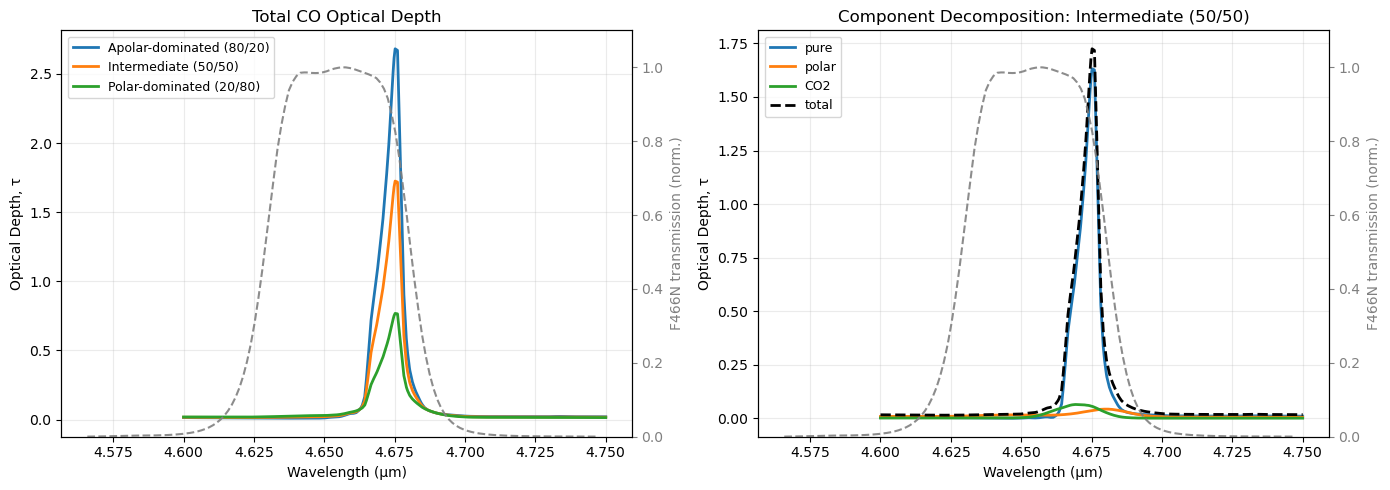

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Left: total profile for each mixture
for label, data in profiles.items():
    axes[0].plot(xarr.value, data['tau_total'], lw=2, label=label)

axes[0].set_title('Total CO Optical Depth')
axes[0].set_xlabel('Wavelength (µm)')
axes[0].set_ylabel('Optical Depth, τ')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(alpha=0.25)

# Overlay F466N transmission on secondary y-axis
ax0b = axes[0].twinx()
ax0b.plot(f466n_wave_um.value, f466n_thr_norm, color='gray', ls='--', lw=1.5, alpha=0.9)
ax0b.set_ylabel('F466N transmission (norm.)', color='gray')
ax0b.tick_params(axis='y', colors='gray')
ax0b.set_ylim(0, 1.1)

# Right: component breakdown for one representative mixture
rep_label = 'Intermediate (50/50)'
rep = profiles[rep_label]
for env_name, tau_comp in rep['tau_components'].items():
    axes[1].plot(xarr.value, tau_comp, lw=2, label=env_name)
axes[1].plot(xarr.value, rep['tau_total'], 'k--', lw=2, label='total')

axes[1].set_title(f'Component Decomposition: {rep_label}')
axes[1].set_xlabel('Wavelength (µm)')
axes[1].set_ylabel('Optical Depth, τ')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].grid(alpha=0.25)

# Overlay F466N transmission on secondary y-axis
ax1b = axes[1].twinx()
ax1b.plot(f466n_wave_um.value, f466n_thr_norm, color='gray', ls='--', lw=1.5, alpha=0.9)
ax1b.set_ylabel('F466N transmission (norm.)', color='gray')
ax1b.tick_params(axis='y', colors='gray')
ax1b.set_ylim(0, 1.1)

plt.tight_layout()

mixture,F466N_rel_flux,F466N_rel_to_baseline,F466N_delta_mag,Delta_mag_vs_baseline
,,,,
str24,float64,float64,float64,float64
Apolar-dominated (80/20),0.8040902864467462,1.0,0.23673796051645854,0.0
Intermediate (50/50),0.8336155210017514,1.036718805154924,0.19758551971231916,-0.03915244080413938
Polar-dominated (20/80),0.8853024220389041,1.1009987770789176,0.13227086905477406,-0.10446709146168448


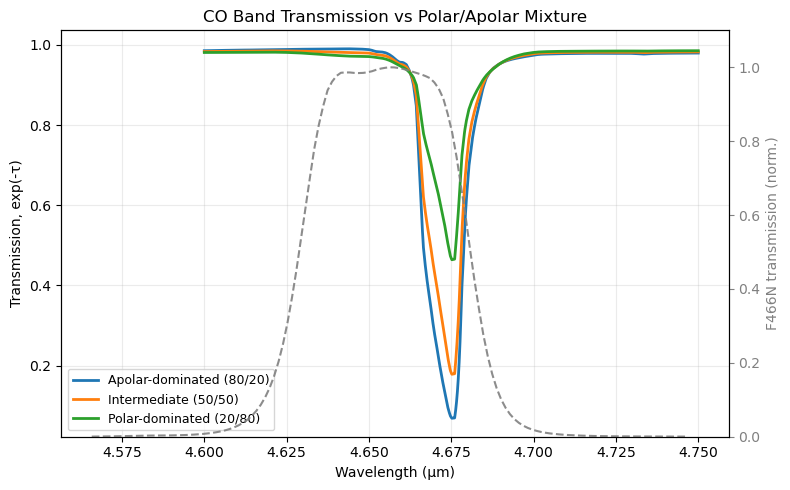

In [82]:
# Show transmission e^(-tau) for each mixture, with F466N bandpass overlay
fig, ax = plt.subplots(figsize=(8, 5))
for label, data in profiles.items():
    transmission = np.exp(-data['tau_total'])
    ax.plot(xarr.value, transmission, lw=2, label=label)

ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel('Transmission, exp(-τ)')
ax.set_title('CO Band Transmission vs Polar/Apolar Mixture')
ax.legend(fontsize=9, loc='lower left')
ax.grid(alpha=0.25)

axb = ax.twinx()
axb.plot(f466n_wave_um.value, f466n_thr_norm, color='gray', ls='--', lw=1.5, alpha=0.9)
axb.set_ylabel('F466N transmission (norm.)', color='gray')
axb.tick_params(axis='y', colors='gray')
axb.set_ylim(0, 1.1)

plt.tight_layout()

mix_table

## Matrix Effect (Bergner-style): CO in H2O Matrix vs CO2 Matrix

This section isolates the matrix effect by comparing profiles at the same CO column density in:
- **H2O-rich (polar) matrix**
- **CO2-rich matrix**

No Gaussian profiles are used; all curves come from lab tables.

In [83]:
N_matrix = 4.0e17 * u.cm**-2

matrix_cases = {
    'H2O matrix (polar CO)': {'pure': 0.0 * u.cm**-2, 'polar': N_matrix, 'CO2': 0.0 * u.cm**-2},
    'CO2 matrix (CO:CO2)': {'pure': 0.0 * u.cm**-2, 'polar': 0.0 * u.cm**-2, 'CO2': N_matrix},
}

matrix_profiles = {}
for label, cols in matrix_cases.items():
    tau_total, tau_components = co_profiles.co_composite_tau(
        cols,
        xarr,
        tables=tables,
        use_gaussian_fallback=False,
    )
    f_rel = f466n_relative_flux_from_tau(tau_total)
    delta_mag = -2.5 * np.log10(f_rel)
    matrix_profiles[label] = {
        'tau_total': tau_total,
        'tau_components': tau_components,
        'f466n_rel_flux': f_rel,
        'f466n_delta_mag': delta_mag,
    }

matrix_rows = []
base_label = 'H2O matrix (polar CO)'
base_flux = matrix_profiles[base_label]['f466n_rel_flux']
base_mag = matrix_profiles[base_label]['f466n_delta_mag']

for label, data in matrix_profiles.items():
    matrix_rows.append({
        'matrix_case': label,
        'F466N_rel_flux': data['f466n_rel_flux'],
        'F466N_rel_to_H2O_matrix': data['f466n_rel_flux'] / base_flux,
        'F466N_delta_mag': data['f466n_delta_mag'],
        'Delta_mag_vs_H2O_matrix': data['f466n_delta_mag'] - base_mag,
    })

matrix_table = Table(rows=matrix_rows)
matrix_table.sort('matrix_case')
matrix_table

matrix_case,F466N_rel_flux,F466N_rel_to_H2O_matrix,F466N_delta_mag,Delta_mag_vs_H2O_matrix
,,,,
str21,float64,float64,float64,float64
CO2 matrix (CO:CO2),0.904312954094962,0.9185843777734072,0.10920311984032616,0.09220236209084234
H2O matrix (polar CO),0.9844636769100753,1.0,0.017000757749483817,0.0


matrix_case,F466N_rel_flux,F466N_rel_to_H2O_matrix,F466N_delta_mag,Delta_mag_vs_H2O_matrix
,,,,
str21,float64,float64,float64,float64
CO2 matrix (CO:CO2),0.904312954094962,0.9185843777734072,0.10920311984032616,0.09220236209084234
H2O matrix (polar CO),0.9844636769100753,1.0,0.017000757749483817,0.0


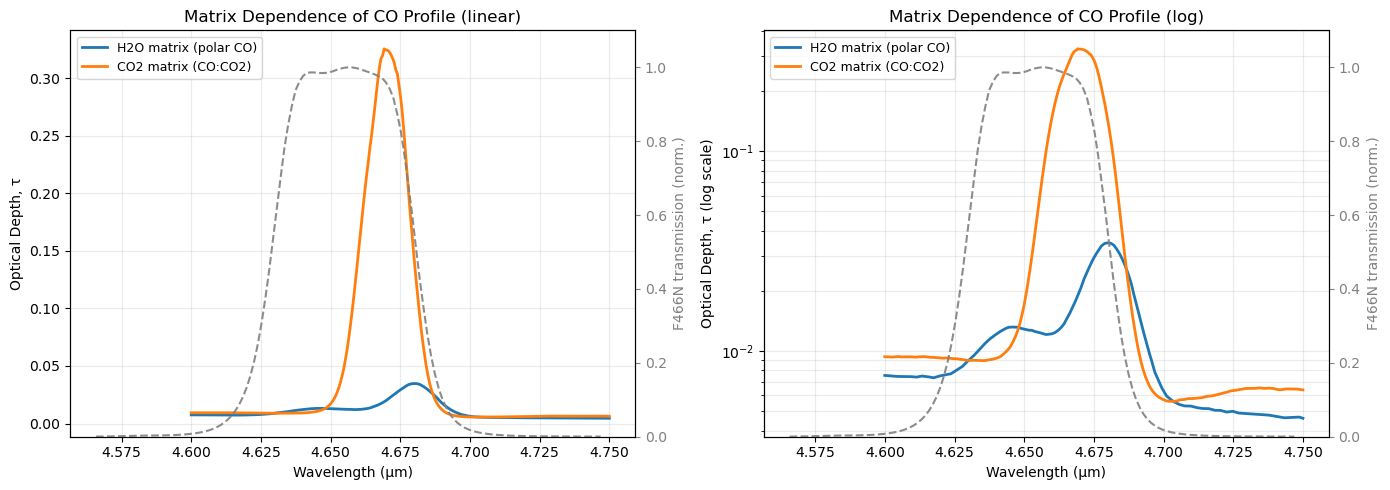

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Left: linear scale (absolute optical depth)
for label, data in matrix_profiles.items():
    axes[0].plot(xarr.value, data['tau_total'], lw=2, label=label)

axes[0].set_xlabel('Wavelength (µm)')
axes[0].set_ylabel('Optical Depth, τ')
axes[0].set_title('Matrix Dependence of CO Profile (linear)')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(alpha=0.25)

ax0b = axes[0].twinx()
ax0b.plot(f466n_wave_um.value, f466n_thr_norm, color='gray', ls='--', lw=1.5, alpha=0.9)
ax0b.set_ylabel('F466N transmission (norm.)', color='gray')
ax0b.tick_params(axis='y', colors='gray')
ax0b.set_ylim(0, 1.1)

# Right: log scale to show weaker H2O:CO peak clearly
for label, data in matrix_profiles.items():
    axes[1].plot(xarr.value, data['tau_total'], lw=2, label=label)

axes[1].set_yscale('log')
axes[1].set_xlabel('Wavelength (µm)')
axes[1].set_ylabel('Optical Depth, τ (log scale)')
axes[1].set_title('Matrix Dependence of CO Profile (log)')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].grid(alpha=0.25, which='both')

ax1b = axes[1].twinx()
ax1b.plot(f466n_wave_um.value, f466n_thr_norm, color='gray', ls='--', lw=1.5, alpha=0.9)
ax1b.set_ylabel('F466N transmission (norm.)', color='gray')
ax1b.tick_params(axis='y', colors='gray')
ax1b.set_ylim(0, 1.1)

plt.tight_layout()

matrix_table

## Side-by-Side Comparison: OCDB vs Bergner

This section compares the same matrix cases using:
- **OCDB optical constants**
- **Bergner Zenodo profiles**

The goal is to visualize differences in CO profile shape and in-band F466N impact for the same nominal column setup.

In [85]:
import importlib
co_profiles = importlib.reload(co_profiles)
assert hasattr(co_profiles, 'download_bergner_co_profiles'), 'co_profiles is outdated in kernel; reload failed'

# Ensure Bergner profiles are available locally (no-op if already downloaded)
_ = co_profiles.download_bergner_co_profiles(redo=False)

def smooth_profile(y, window=31):
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(y, kernel, mode='same')

# Explicit Bergner files for matrix comparison (avoid weak/noisy auto picks)
bergner_cache = icemodels.core.optical_constants_cache_dir
bergner_file_map = {
    'pure': os.path.join(bergner_cache, 'bergner_13948083_CO_10K.txt'),
    'polar': os.path.join(bergner_cache, 'bergner_13948069_Polar-10-1-1_10K.txt'),
    'CO2': os.path.join(bergner_cache, 'bergner_13948083_Apolar-1-10_10K.txt'),
}
for env, fn in bergner_file_map.items():
    assert os.path.exists(fn), f'Missing Bergner file for {env}: {fn}'
bergner_tables = {env: co_profiles.read_bergner_file(fn) for env, fn in bergner_file_map.items()}
print('Using explicit Bergner files:')
for env, fn in bergner_file_map.items():
    print(f'  {env:>5}: {os.path.basename(fn)}')

comparison_profiles = {'ocdb': {}, 'bergner_raw': {}, 'bergner_peakmatched': {}}
comparison_rows = []

# Build OCDB and raw Bergner profiles for the same matrix cases
for db in ('ocdb', 'bergner'):
    store_key = db if db == 'ocdb' else 'bergner_raw'
    for label, cols in matrix_cases.items():
        if db == 'bergner':
            tau_total, tau_components = co_profiles.co_composite_tau(
                cols,
                xarr,
                tables=bergner_tables,
                use_gaussian_fallback=False,
            )
        else:
            tau_total, tau_components = co_profiles.co_composite_tau(
                cols,
                xarr,
                database='ocdb',
                temperature=10,
                use_gaussian_fallback=False,
            )
        f_rel = f466n_relative_flux_from_tau(tau_total)
        delta_mag = -2.5 * np.log10(f_rel)
        comparison_profiles[store_key][label] = {
            'tau_total': tau_total,
            'tau_components': tau_components,
            'f466n_rel_flux': f_rel,
            'f466n_delta_mag': delta_mag,
        }
        comparison_rows.append({
            'database': store_key,
            'matrix_case': label,
            'F466N_rel_flux': f_rel,
            'F466N_delta_mag': delta_mag,
        })

# Derive component-wise scale factors so Bergner and OCDB have comparable amplitude
N_ref = 4.0e17 * u.cm**-2
component_scale = {}
for env in ('pure', 'polar', 'CO2'):
    tau_ocdb, _ = co_profiles.co_composite_tau(
        {env: N_ref},
        xarr,
        database='ocdb',
        temperature=10,
        use_gaussian_fallback=False,
    )
    tau_bergner, _ = co_profiles.co_composite_tau(
        {env: N_ref},
        xarr,
        tables={env: bergner_tables[env]},
        use_gaussian_fallback=False,
    )
    tau_bergner_sm = smooth_profile(tau_bergner, window=31)
    amp_ocdb = np.nanpercentile(tau_ocdb, 99.5)
    amp_bergner = np.nanpercentile(tau_bergner_sm, 99.5)
    raw_scale = amp_ocdb / max(amp_bergner, 1e-8)
    component_scale[env] = min(raw_scale, 25.0)

scale_table = Table(rows=[
    {'component': k, 'peak_scale_ocdb_over_bergner': v}
    for k, v in component_scale.items()
], names=['component', 'peak_scale_ocdb_over_bergner'])
scale_table.sort('component')
print('Applied Bergner robust peak-matching scale factors (to OCDB):')
scale_table

# Build peak-matched Bergner matrix-case profiles using smoothed components
for label, data in comparison_profiles['bergner_raw'].items():
    tau_scaled = np.zeros_like(data['tau_total'])
    for env, tau_comp in data['tau_components'].items():
        tau_comp_sm = smooth_profile(tau_comp, window=31)
        tau_scaled += component_scale[env] * tau_comp_sm
    f_rel = f466n_relative_flux_from_tau(tau_scaled)
    delta_mag = -2.5 * np.log10(f_rel)
    comparison_profiles['bergner_peakmatched'][label] = {
        'tau_total': tau_scaled,
        'tau_components': data['tau_components'],
        'f466n_rel_flux': f_rel,
        'f466n_delta_mag': delta_mag,
    }
    comparison_rows.append({
        'database': 'bergner_peakmatched',
        'matrix_case': label,
        'F466N_rel_flux': f_rel,
        'F466N_delta_mag': delta_mag,
    })

comparison_table = Table(rows=comparison_rows)
comparison_table.sort(['database', 'matrix_case'])
comparison_table

Using explicit Bergner files:
   pure: bergner_13948083_CO_10K.txt
  polar: bergner_13948069_Polar-10-1-1_10K.txt
    CO2: bergner_13948083_Apolar-1-10_10K.txt
Applied Bergner robust peak-matching scale factors (to OCDB):


database,matrix_case,F466N_rel_flux,F466N_delta_mag
,,,
str19,str21,float64,float64
bergner_peakmatched,CO2 matrix (CO:CO2),0.9684252940885673,0.034834689598815916
bergner_peakmatched,H2O matrix (polar CO),0.9838338844296854,0.017695559728828438
bergner_raw,CO2 matrix (CO:CO2),0.995050158347641,0.00538756711919639
bergner_raw,H2O matrix (polar CO),0.9986772199426089,0.0014371409196070413
ocdb,CO2 matrix (CO:CO2),0.904312954094962,0.10920311984032616
ocdb,H2O matrix (polar CO),0.9844636769100753,0.017000757749483817


database,H2O_F466N_rel_flux,CO2_F466N_rel_flux,CO2_over_H2O_flux,Delta_mag_CO2_minus_H2O
,,,,
str19,float64,float64,float64,float64
bergner_peakmatched,0.9838338844296854,0.9684252940885673,0.9843382195053687,0.017139129869987477
bergner_raw,0.9986772199426089,0.995050158347641,0.9963681342454408,0.0039504261995893485
ocdb,0.9844636769100753,0.904312954094962,0.9185843777734072,0.09220236209084234


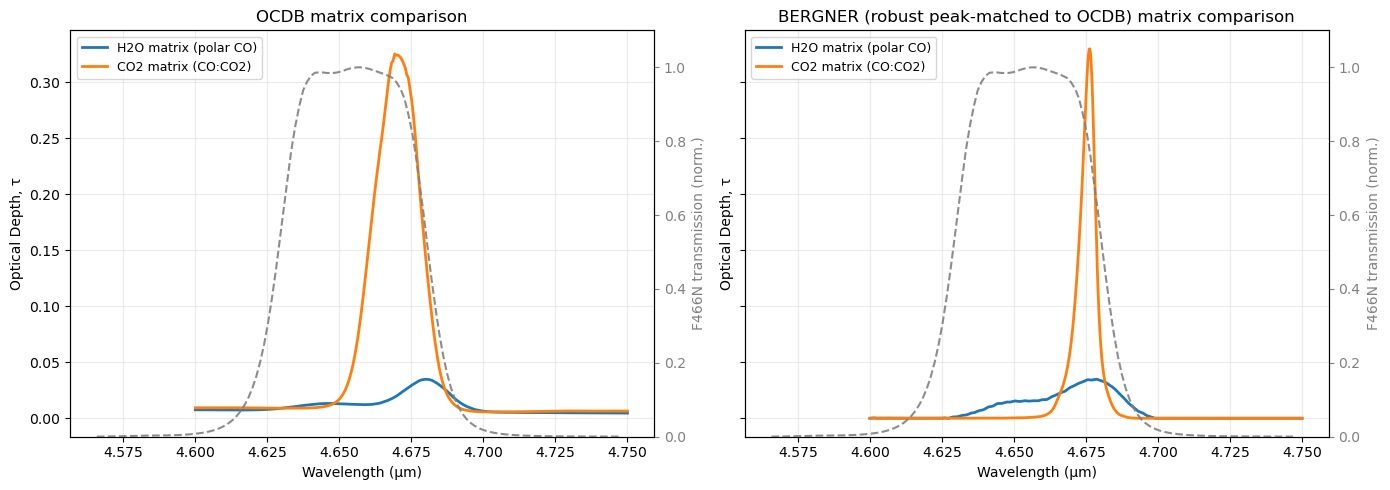

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

panel_map = [('ocdb', 'OCDB'), ('bergner_peakmatched', 'BERGNER (robust peak-matched to OCDB)')]
for ax, (db, title) in zip(axes, panel_map):
    for label, data in comparison_profiles[db].items():
        ax.plot(xarr.value, data['tau_total'], lw=2, label=label)

    ax.set_xlabel('Wavelength (µm)')
    ax.set_ylabel('Optical Depth, τ')
    ax.set_title(f'{title} matrix comparison')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9, loc='upper left')

    axb = ax.twinx()
    axb.plot(f466n_wave_um.value, f466n_thr_norm, color='gray', ls='--', lw=1.5, alpha=0.9)
    axb.set_ylabel('F466N transmission (norm.)', color='gray')
    axb.tick_params(axis='y', colors='gray')
    axb.set_ylim(0, 1.1)

plt.tight_layout()

# Add per-database relative summary (CO2 matrix relative to H2O matrix)
summary_rows = []
for db in ('ocdb', 'bergner_raw', 'bergner_peakmatched'):
    h2o = comparison_profiles[db]['H2O matrix (polar CO)']
    co2 = comparison_profiles[db]['CO2 matrix (CO:CO2)']
    summary_rows.append({
        'database': db,
        'H2O_F466N_rel_flux': h2o['f466n_rel_flux'],
        'CO2_F466N_rel_flux': co2['f466n_rel_flux'],
        'CO2_over_H2O_flux': co2['f466n_rel_flux'] / h2o['f466n_rel_flux'],
        'Delta_mag_CO2_minus_H2O': co2['f466n_delta_mag'] - h2o['f466n_delta_mag'],
    })

comparison_summary = Table(rows=summary_rows)
comparison_summary.sort('database')
comparison_summary

## Normalization Check: Fixed CO vs Fixed Total Ice

This section isolates normalization effects by comparing matrix cases under two setups:
- **Fixed CO column**: same $N_{\rm CO}$ for H2O-matrix and CO2-matrix cases.
- **Fixed total ice column**: same $N_{\rm ice}$; then $N_{\rm CO}=f_{\rm CO}\,N_{\rm ice}$ depends on mixture ratio.

If differences shrink under fixed CO, then the prior amplitude contrast was largely a CO-fraction/dilution effect.

In [87]:
# Build/refresh Bergner explicit tables if needed
if 'bergner_tables' not in globals():
    _ = co_profiles.download_bergner_co_profiles(redo=False)
    bergner_cache = icemodels.core.optical_constants_cache_dir
    bergner_file_map = {
        'pure': os.path.join(bergner_cache, 'bergner_13948083_CO_10K.txt'),
        'polar': os.path.join(bergner_cache, 'bergner_13948069_Polar-10-1-1_10K.txt'),
        'CO2': os.path.join(bergner_cache, 'bergner_13948083_Apolar-1-10_10K.txt'),
    }
    bergner_tables = {env: co_profiles.read_bergner_file(fn) for env, fn in bergner_file_map.items()}

def co_fraction_from_ocdb_table(tbl):
    mols, ratios = icemodels.core.parse_molscomps(tbl.meta['composition'])
    total = np.sum(ratios)
    for mol, ratio in zip(mols, ratios):
        if mol.strip().upper() == 'CO':
            return float(ratio) / float(total)
    raise ValueError(f"No CO component found in composition: {tbl.meta['composition']}")

# CO fractions used in fixed-total-ice mode
co_fraction = {
    'ocdb': {
        'H2O matrix (polar CO)': co_fraction_from_ocdb_table(tables['polar']),
        'CO2 matrix (CO:CO2)': co_fraction_from_ocdb_table(tables['CO2']),
    },
    # For explicit Bergner files: Polar-10-1-1 and Apolar-1-10
    # Interpreted as component ratios with CO fraction 1/(10+1+1) and 1/(1+10).
    'bergner': {
        'H2O matrix (polar CO)': 1.0 / 12.0,
        'CO2 matrix (CO:CO2)': 1.0 / 11.0,
    },
}

N_CO_fixed = 4.0e17 * u.cm**-2
N_ice_fixed = 1.0e19 * u.cm**-2

norm_modes = ('fixed_co', 'fixed_total_ice')
norm_profiles = {mode: {'ocdb': {}, 'bergner': {}} for mode in norm_modes}
norm_rows = []

for mode in norm_modes:
    for db in ('ocdb', 'bergner'):
        for case in ('H2O matrix (polar CO)', 'CO2 matrix (CO:CO2)'):
            if mode == 'fixed_co':
                N_co_case = N_CO_fixed
            else:
                N_co_case = co_fraction[db][case] * N_ice_fixed

            cols = {'pure': 0.0 * u.cm**-2, 'polar': 0.0 * u.cm**-2, 'CO2': 0.0 * u.cm**-2}
            if case == 'H2O matrix (polar CO)':
                cols['polar'] = N_co_case
            else:
                cols['CO2'] = N_co_case

            if db == 'ocdb':
                tau_total, _ = co_profiles.co_composite_tau(
                    cols, xarr, database='ocdb', temperature=10, use_gaussian_fallback=False
                )
            else:
                tau_total, _ = co_profiles.co_composite_tau(
                    cols, xarr, tables=bergner_tables, use_gaussian_fallback=False
                )

            f_rel = f466n_relative_flux_from_tau(tau_total)
            dmag = -2.5 * np.log10(f_rel)
            norm_profiles[mode][db][case] = {'tau_total': tau_total, 'f466n_rel_flux': f_rel, 'dmag': dmag, 'N_co': N_co_case}

            norm_rows.append({
                'mode': mode,
                'database': db,
                'matrix_case': case,
                'f_CO_for_fixed_total_ice': co_fraction[db][case],
                'N_CO_used_cm-2': N_co_case.to_value(u.cm**-2),
                'tau_peak': float(np.nanmax(tau_total)),
                'F466N_rel_flux': f_rel,
                'F466N_delta_mag': dmag,
            })

norm_table = Table(rows=norm_rows)
norm_table.sort(['mode', 'database', 'matrix_case'])
norm_table

mode,database,matrix_case,f_CO_for_fixed_total_ice,N_CO_used_cm-2,tau_peak,F466N_rel_flux,F466N_delta_mag
,,,,,,,
str15,str7,str21,float64,float64,float64,float64,float64
fixed_co,bergner,CO2 matrix (CO:CO2),0.09090909090909091,4e+17,0.04850414442999169,0.995050158347641,0.00538756711919639
fixed_co,bergner,H2O matrix (polar CO),0.08333333333333333,4e+17,0.0028334600891170556,0.9986772199426089,0.0014371409196070413
fixed_co,ocdb,CO2 matrix (CO:CO2),0.5882352941176471,4e+17,0.3255061187663383,0.904312954094962,0.10920311984032616
fixed_co,ocdb,H2O matrix (polar CO),0.047619047619047616,4e+17,0.03480751220971438,0.9844636769100753,0.017000757749483817
fixed_total_ice,bergner,CO2 matrix (CO:CO2),0.09090909090909091,9.09090909090909e+17,0.11023669188634473,0.988956002548695,0.012057573017556542
fixed_total_ice,bergner,H2O matrix (polar CO),0.08333333333333333,8.333333333333332e+17,0.005903041852327199,0.9972469303771616,0.0029932295415767375
fixed_total_ice,ocdb,CO2 matrix (CO:CO2),0.5882352941176471,5.882352941176471e+18,4.786854687740269,0.4852232057431261,0.7851460930648174
fixed_total_ice,ocdb,H2O matrix (polar CO),0.047619047619047616,4.7619047619047616e+17,0.041437514535374254,0.98153770739504,0.020232529006012273


mode,database,matrix_case,f_CO_for_fixed_total_ice,N_CO_used_cm-2,tau_peak,F466N_rel_flux,F466N_delta_mag
,,,,,,,
str15,str7,str21,float64,float64,float64,float64,float64
fixed_co,bergner,CO2 matrix (CO:CO2),0.09090909090909091,4e+17,0.04850414442999169,0.995050158347641,0.00538756711919639
fixed_co,bergner,H2O matrix (polar CO),0.08333333333333333,4e+17,0.0028334600891170556,0.9986772199426089,0.0014371409196070413
fixed_co,ocdb,CO2 matrix (CO:CO2),0.5882352941176471,4e+17,0.3255061187663383,0.904312954094962,0.10920311984032616
fixed_co,ocdb,H2O matrix (polar CO),0.047619047619047616,4e+17,0.03480751220971438,0.9844636769100753,0.017000757749483817
fixed_total_ice,bergner,CO2 matrix (CO:CO2),0.09090909090909091,9.09090909090909e+17,0.11023669188634473,0.988956002548695,0.012057573017556542
fixed_total_ice,bergner,H2O matrix (polar CO),0.08333333333333333,8.333333333333332e+17,0.005903041852327199,0.9972469303771616,0.0029932295415767375
fixed_total_ice,ocdb,CO2 matrix (CO:CO2),0.5882352941176471,5.882352941176471e+18,4.786854687740269,0.4852232057431261,0.7851460930648174
fixed_total_ice,ocdb,H2O matrix (polar CO),0.047619047619047616,4.7619047619047616e+17,0.041437514535374254,0.98153770739504,0.020232529006012273


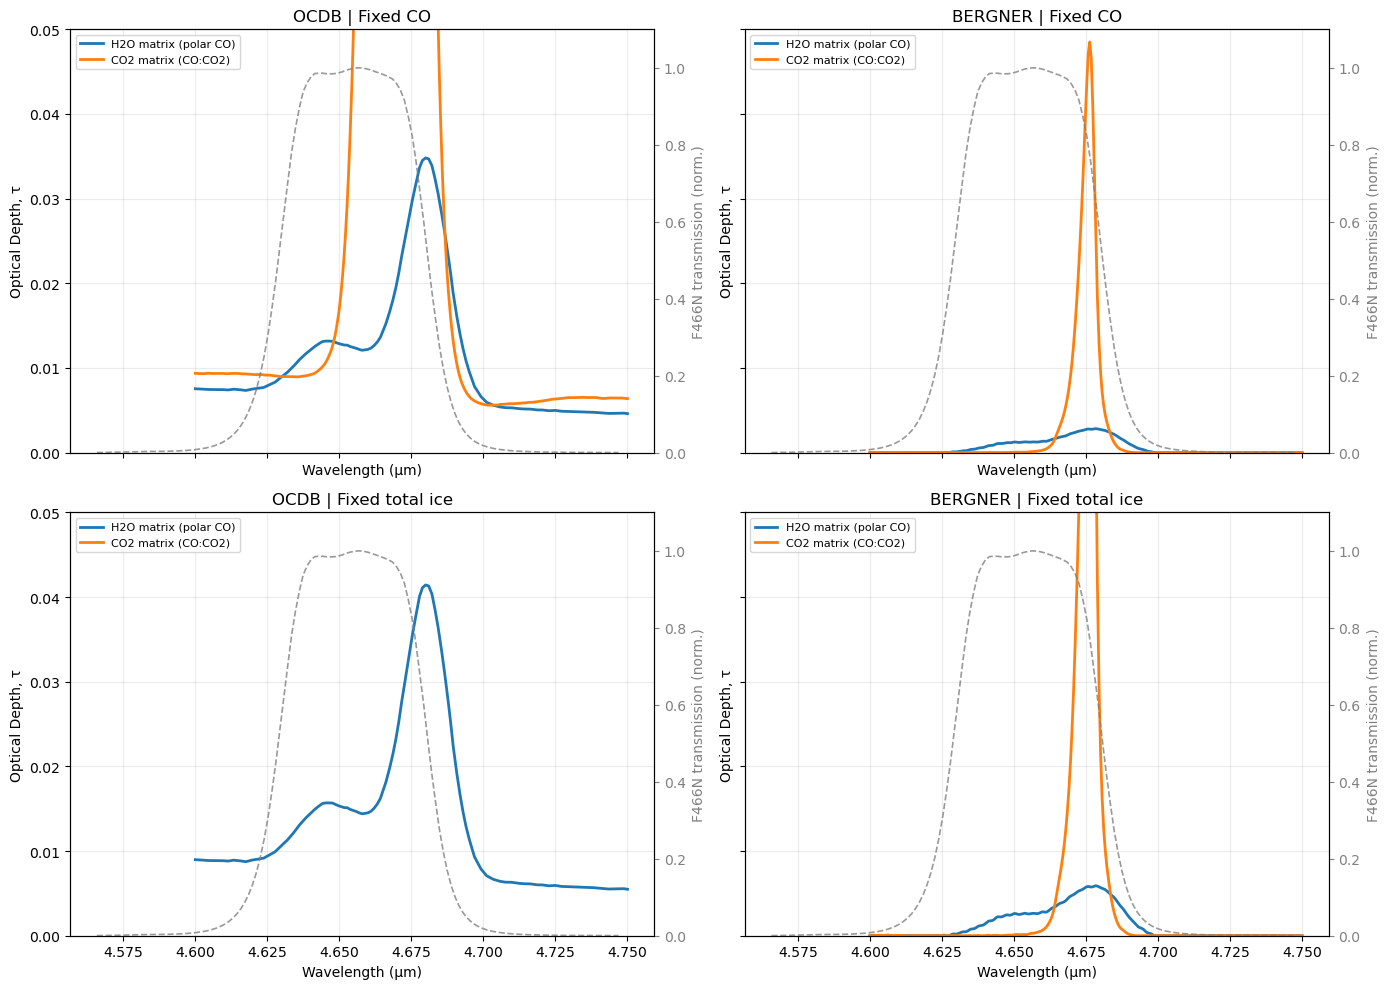

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
layout = [('fixed_co', 'ocdb'), ('fixed_co', 'bergner'), ('fixed_total_ice', 'ocdb'), ('fixed_total_ice', 'bergner')]

for ax, (mode, db) in zip(axes.flat, layout):
    for case, data in norm_profiles[mode][db].items():
        ax.plot(xarr.value, data['tau_total'], lw=2, label=case)

    title_mode = 'Fixed CO' if mode == 'fixed_co' else 'Fixed total ice'
    ax.set_title(f'{db.upper()} | {title_mode}')
    ax.set_xlabel('Wavelength (µm)')
    ax.set_ylabel('Optical Depth, τ')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylim(0, 0.05)

    axb = ax.twinx()
    axb.plot(f466n_wave_um.value, f466n_thr_norm, color='gray', ls='--', lw=1.2, alpha=0.8)
    axb.set_ylim(0, 1.1)
    axb.set_ylabel('F466N transmission (norm.)', color='gray')
    axb.tick_params(axis='y', colors='gray')

plt.tight_layout()

norm_table

## Notes

- The **apolar/pure** component contributes a narrower feature near the canonical CO center.
- Increasing the **polar (H2O-matrix)** fraction broadens and shifts the blended profile shape.
- The notebook computes **F466N in-band relative flux** and corresponding **magnitude change** ($\Delta m=-2.5\log_{10} F_{\rm rel}$) for each case.
- Both the mixture and matrix-comparison sections include tables with relative differences.
- This notebook uses **no simple-Gaussian profile generation**; all components come from loaded lab tables.